# Crop Yield Prediction Analysis 🌾

This notebook demonstrates the process of predicting crop yield based on various environmental factors.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression
df = pd.read_csv("yield_df.csv")

ModuleNotFoundError: No module named 'pandas'

In [ ]:
df.head()


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB


In [ ]:

df.describe()

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


In [ ]:

df.isnull().sum()

Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(28242, 8)

In [ ]:
print(df.columns)

Index(['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'],
      dtype='object')


In [ ]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
print(df.columns)

Index(['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='object')


## Exploratory Data Analysis (EDA) 📊

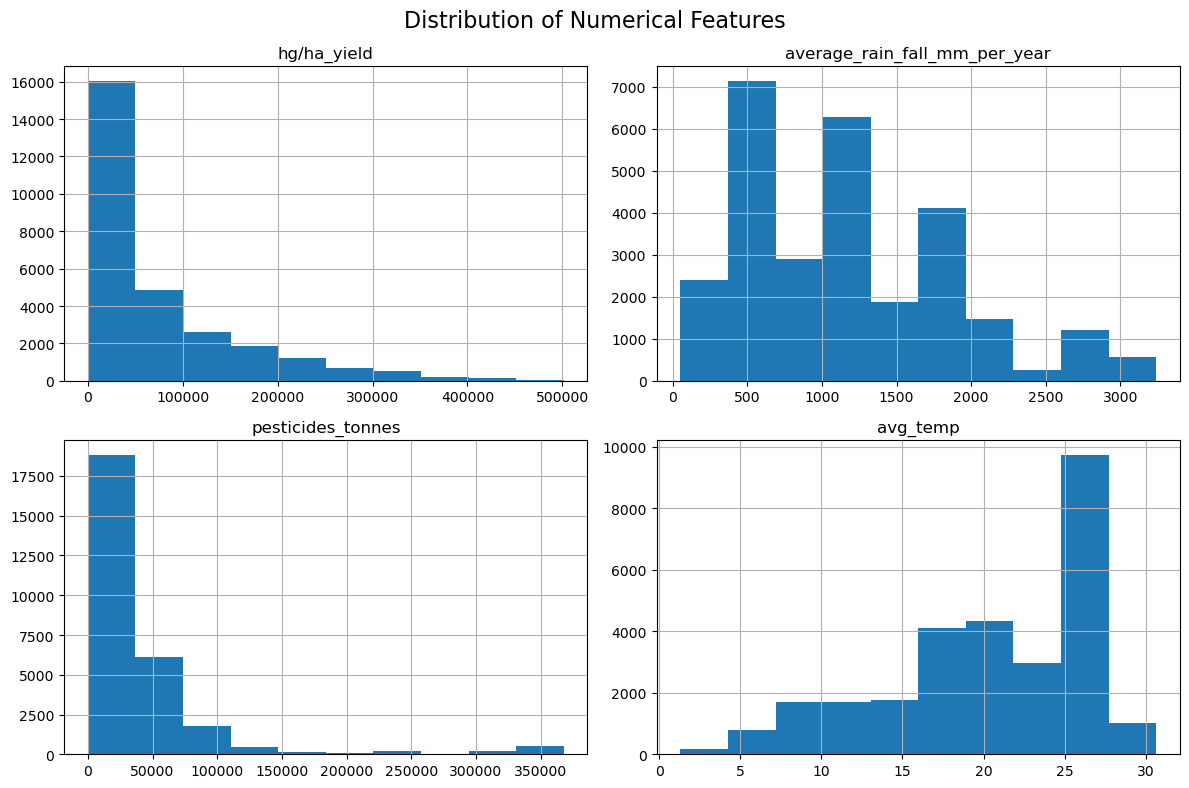

202

In [ ]:
df[['Area',
    'hg/ha_yield',
    'average_rain_fall_mm_per_year',
    'pesticides_tonnes',
    'avg_temp']].hist(figsize=(12,8))
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.savefig("Feature_Distribution.png")
plt.show()
202

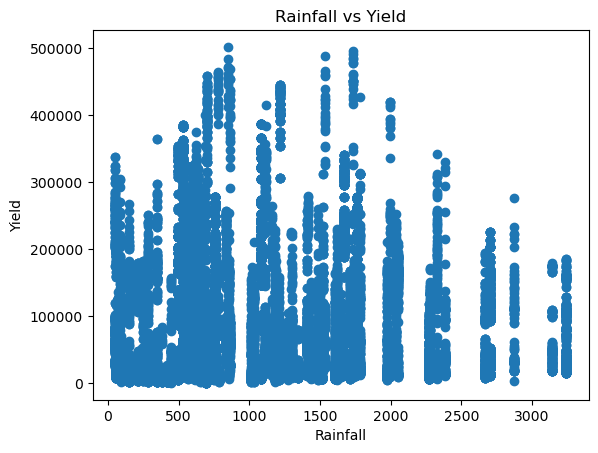

In [ ]:
# scatter plot
plt.scatter(df['average_rain_fall_mm_per_year'], df['hg/ha_yield'])

plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.title("Rainfall vs Yield")

plt.show()

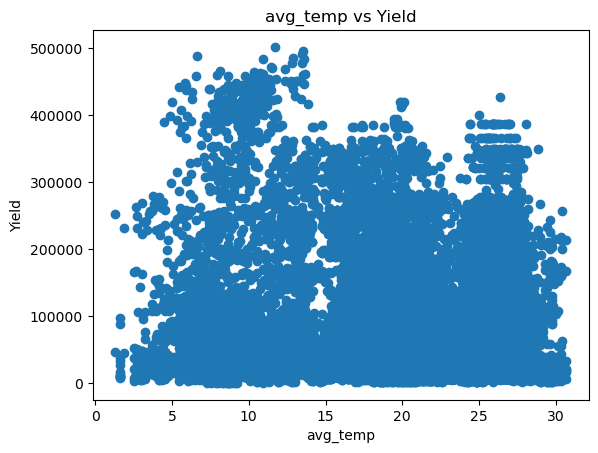

In [ ]:
# scatter plot
plt.scatter(df['avg_temp'], df['hg/ha_yield'])

plt.xlabel("avg_temp")
plt.ylabel("Yield")
plt.title("avg_temp vs Yield")

plt.show()

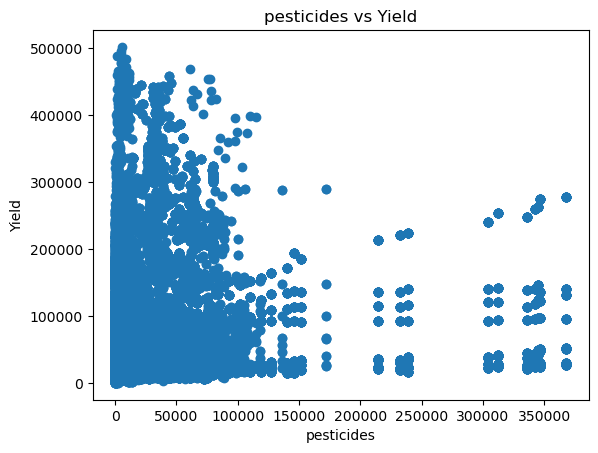

In [ ]:
# scatter plot
plt.scatter(df['pesticides_tonnes'], df['hg/ha_yield'])

plt.xlabel("pesticides")
plt.ylabel("Yield")
plt.title("pesticides vs Yield")

plt.show()

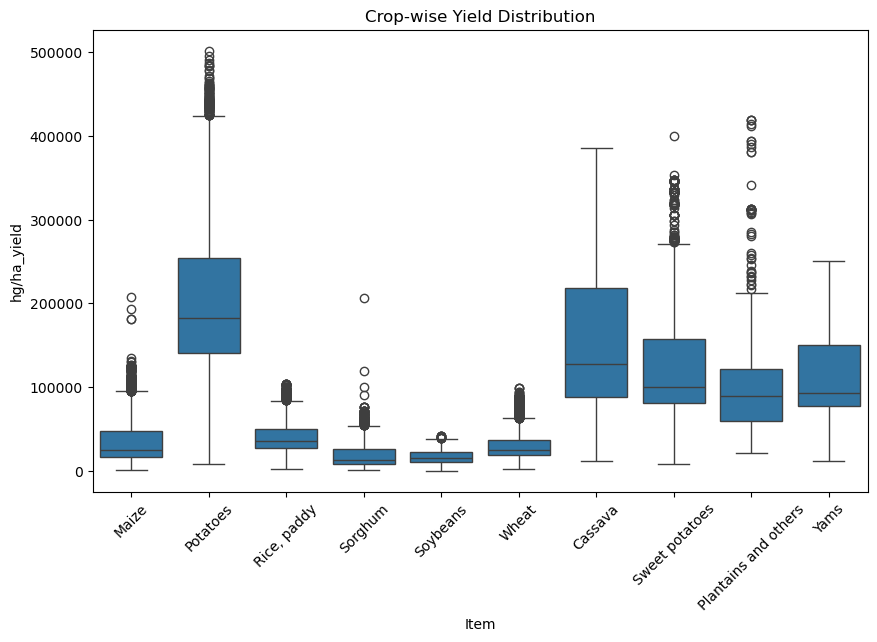

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(x='Item', y='hg/ha_yield', data=df)

plt.xticks(rotation=45)
plt.title("Crop-wise Yield Distribution")

plt.show()

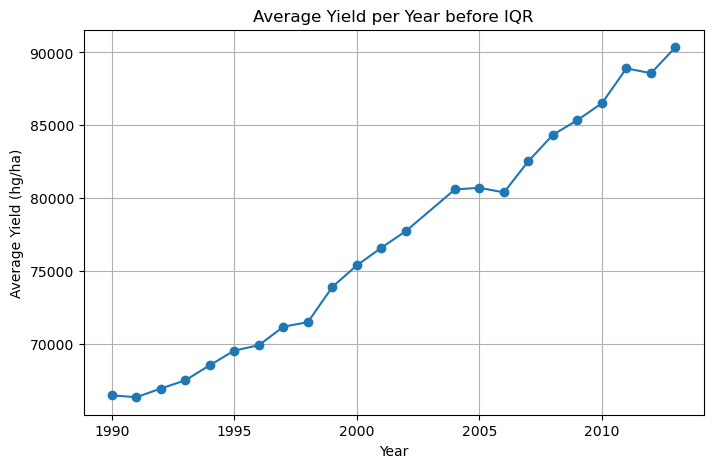

In [ ]:

# Group by Year and calculate mean yield
yearly_yield = df.groupby('Year')['hg/ha_yield'].mean()

# Plot
plt.figure(figsize=(8,5))
plt.plot(yearly_yield.index, yearly_yield.values, marker='o')

# Labels and title
plt.title('Average Yield per Year before IQR')
plt.xlabel('Year')
plt.ylabel('Average Yield (hg/ha)')

plt.grid()
plt.show()

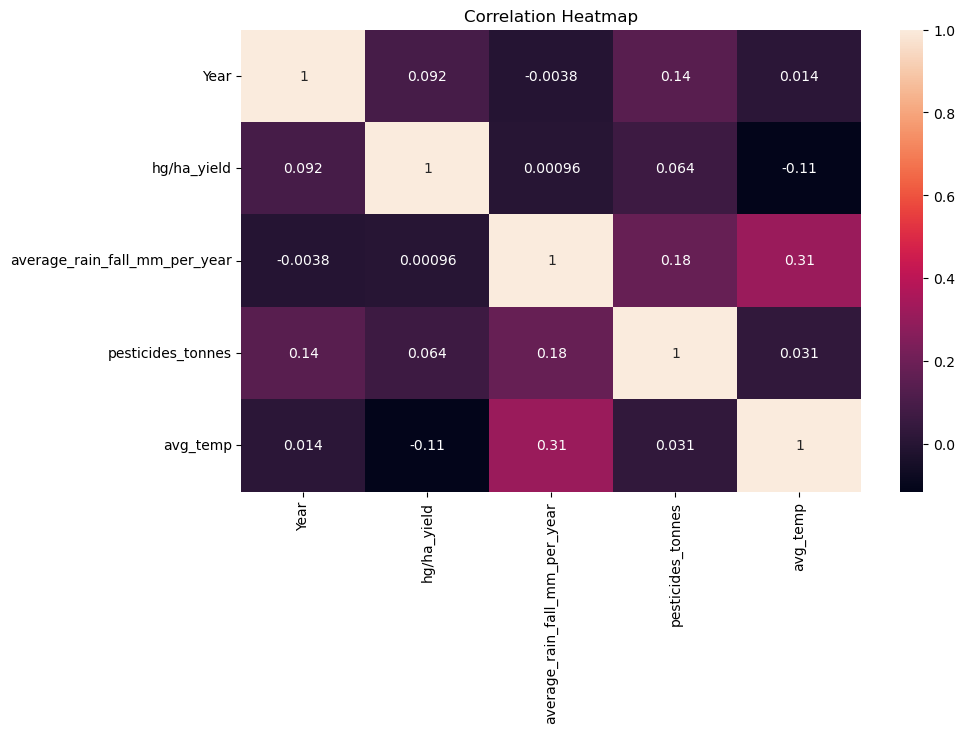

In [ ]:

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.savefig("correlation.png")
plt.show()

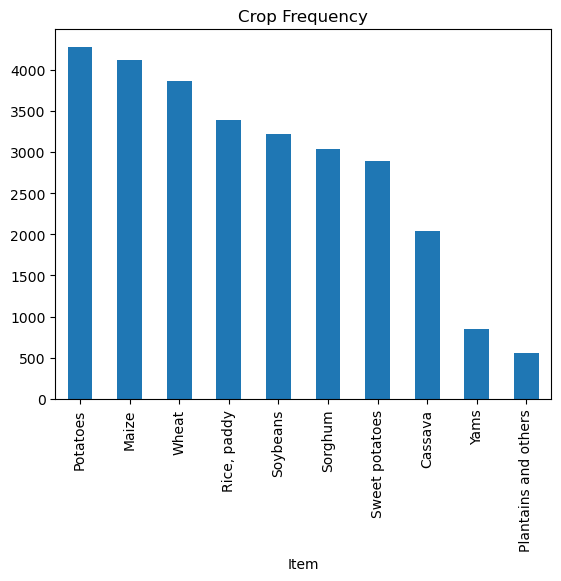

In [ ]:
df['Item'].value_counts().plot(kind='bar', title="Crop Frequency")
plt.show()

Item
Potatoes                199801.549579
Cassava                 150479.466993
Sweet potatoes          119057.793772
Yams                    114140.345927
Plantains and others    106041.320144
Rice, paddy              40730.434770
Maize                    36310.070614
Wheat                    30116.267825
Sorghum                  18635.777229
Soybeans                 16731.092771
Name: hg/ha_yield, dtype: float64


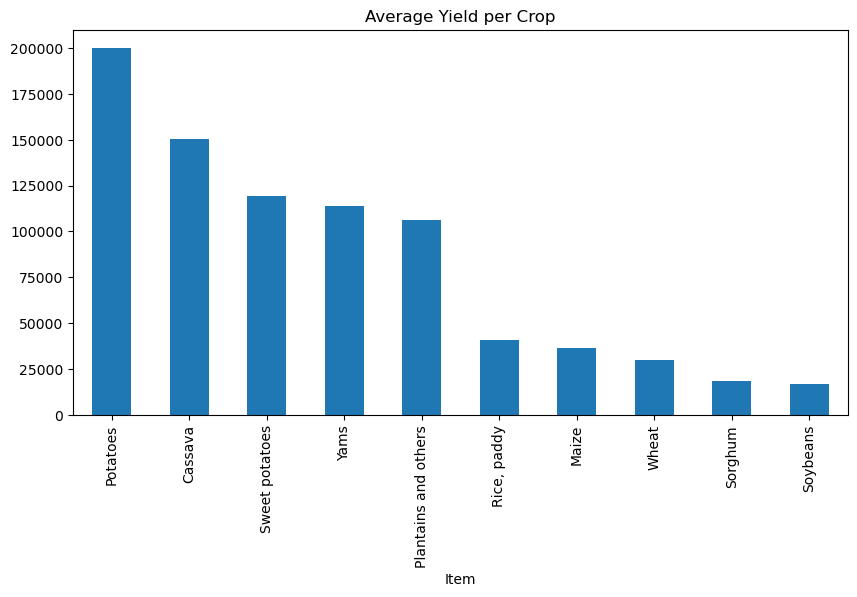

In [ ]:
crop_yield = df.groupby('Item')['hg/ha_yield'].mean().sort_values(ascending=False)
print(crop_yield)
crop_yield.plot(kind='bar', figsize=(10,5), title="Average Yield per Crop")
plt.show()

In [ ]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    print(col, ((df[col] < lower) | (df[col] > upper)).sum())

Year 0
hg/ha_yield 2059
average_rain_fall_mm_per_year 0
pesticides_tonnes 1418
avg_temp 34


In [ ]:
df['hg/ha_yield'] = np.log1p(df['hg/ha_yield'])

In [ ]:
df['pesticides_tonnes'] = np.log1p(df['pesticides_tonnes'])

In [ ]:
Q1 = df['avg_temp'].quantile(0.25)
Q3 = df['avg_temp'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['avg_temp'] = df['avg_temp'].clip(lower, upper)

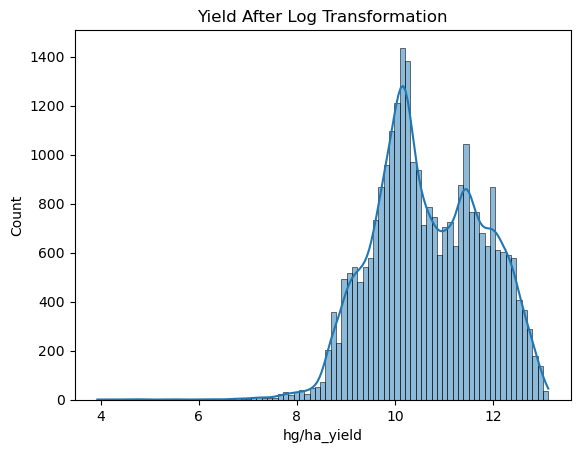

In [ ]:
sns.histplot(df['hg/ha_yield'], kde=True)
plt.title("Yield After Log Transformation")
plt.show()

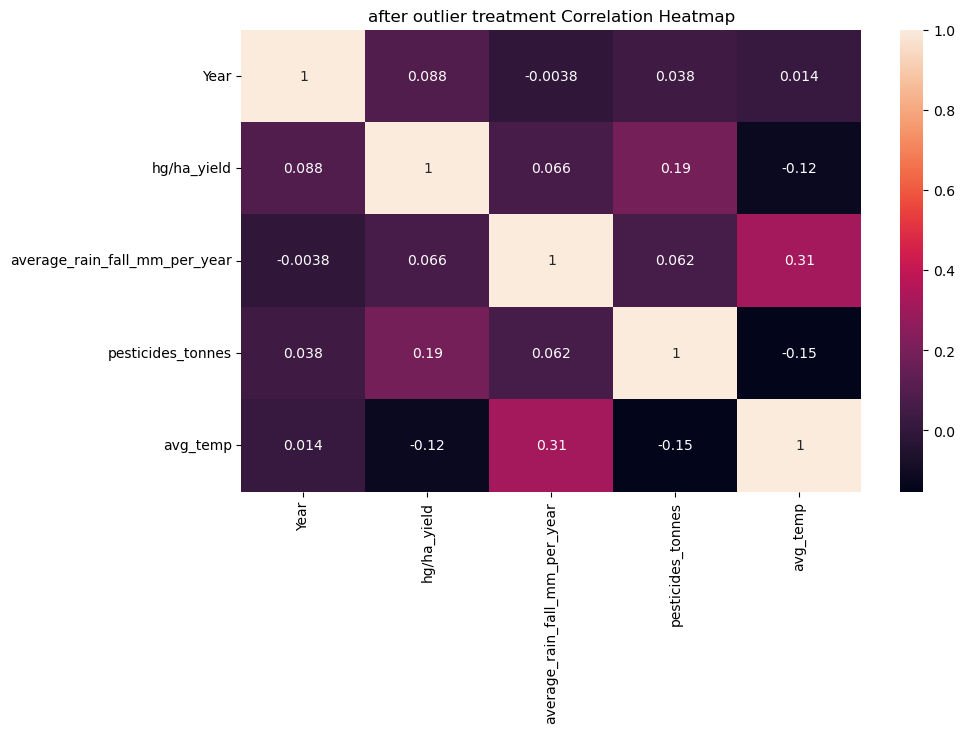

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True)
plt.title("after outlier treatment Correlation Heatmap")
plt.savefig("after_outlier_treatment_correlation.png")
plt.show()

In [ ]:
df = pd.get_dummies(df, columns=['Item'], drop_first=True)

In [ ]:
print(df.columns)

Index(['Area', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp', 'Item_Maize',
       'Item_Plantains and others', 'Item_Potatoes', 'Item_Rice, paddy',
       'Item_Sorghum', 'Item_Soybeans', 'Item_Sweet potatoes', 'Item_Wheat',
       'Item_Yams'],
      dtype='object')


## Model Building and Evaluation 🚀

In [ ]:
# Features and Target
X = df[[ 'Year', 'average_rain_fall_mm_per_year', 
        'pesticides_tonnes', 'avg_temp', 'Item_Maize',
        'Item_Plantains and others', 'Item_Potatoes', 'Item_Rice, paddy',
        'Item_Sorghum', 'Item_Soybeans', 'Item_Sweet potatoes', 
        'Item_Wheat', 'Item_Yams']]

y = df['hg/ha_yield']
print(X.dtypes)
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit only on train
X_test_scaled = scaler.transform(X_test)         # transform test

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)


# Metrics
mae = mean_absolute_error(y_test, y_pred_lr)   # average error
mse = mean_squared_error(y_test, y_pred_lr)    # penalizes large errors
rmse = np.sqrt(mse)                           # human-readable error

# Print results
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

Year                               int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
Item_Maize                          bool
Item_Plantains and others           bool
Item_Potatoes                       bool
Item_Rice, paddy                    bool
Item_Sorghum                        bool
Item_Soybeans                       bool
Item_Sweet potatoes                 bool
Item_Wheat                          bool
Item_Yams                           bool
dtype: object
MAE: 0.4177779720866384
MSE: 0.30339554229361476
RMSE: 0.5508135276966378
Linear Regression R2: 0.7523797357707851


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Prediction
y_pred_rf = rf.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)

# Print all results
print("Random Forest R2:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

Random Forest R2: 0.979080382375747
MAE: 0.0736273544221142
MSE: 0.025631661259395692
RMSE: 0.16009891086261546


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Model
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Prediction
y_pred_knn = knn.predict(X_test_scaled)

# Metrics
r2 = r2_score(y_test, y_pred_knn)
mae = mean_absolute_error(y_test, y_pred_knn)
mse = mean_squared_error(y_test, y_pred_knn)
rmse = np.sqrt(mse)

# Print results
print("KNN R2:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

KNN R2: 0.9418438420881551
MAE: 0.14336817017648254
MSE: 0.07125555383078191
RMSE: 0.2669373593762812


In [ ]:
import pandas as pd

# ----- USER INPUT -----
year = int(input("Enter Year: "))
rain = float(input("Enter Average Rainfall (mm/year): "))
pesticides = float(input("Enter Pesticides (tonnes): "))
temp = float(input("Enter Average Temperature: "))
crop = input("Enter Crop (Maize, Potatoes, Rice, Wheat, etc): ").lower()

# ----- ONE-HOT ENCODING -----
# Initialize all crops as 0
crop_dict = {
    'Item_Maize': 0,
    'Item_Plantains and others': 0,
    'Item_Potatoes': 0,
    'Item_Rice, paddy': 0,
    'Item_Sorghum': 0,
    'Item_Soybeans': 0,
    'Item_Sweet potatoes': 0,
    'Item_Wheat': 0,
    'Item_Yams': 0
}

# Set selected crop = 1
if crop == "maize":
    crop_dict['Item_Maize'] = 1
elif crop == "potatoes":
    crop_dict['Item_Potatoes'] = 1
elif crop == "rice":
    crop_dict['Item_Rice, paddy'] = 1
elif crop == "wheat":
    crop_dict['Item_Wheat'] = 1
elif crop == "sorghum":
    crop_dict['Item_Sorghum'] = 1
elif crop == "soybeans":
    crop_dict['Item_Soybeans'] = 1
elif crop == "sweet potatoes":
    crop_dict['Item_Sweet potatoes'] = 1
elif crop == "yams":
    crop_dict['Item_Yams'] = 1
elif crop == "plantains":
    crop_dict['Item_Plantains and others'] = 1
else:
    print("Invalid crop! Please enter correctly.")

# ----- CREATE INPUT DATA -----
input_data = [[
    year,
    rain,
    pesticides,
    temp,
    *crop_dict.values()
]]

# Convert to DataFrame
input_df = pd.DataFrame(input_data, columns=X.columns)

# ----- PREDICT -----
prediction = rf.predict(input_df)

print("Year:", year)
print("Rainfall:", rain)
print("Pesticides:", pesticides)
print("Temperature:", temp)
print("Crop:", crop)
print("\nðŸŒ¾ Predicted Crop Yield:", prediction[0])


# reverse the standard scaler

Year: 2021
Rainfall: 2300.0
Pesticides: 4500.0
Temperature: 23.0
Crop: maize

ðŸŒ¾ Predicted Crop Yield: 10.534146048711094


In [ ]:
import joblib
joblib.dump(rf, "yield_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Model and Scaler saved successfully!")